In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from datasets import Dataset
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

import torch
from torch.utils.data import DataLoader

In [ ]:
# Loading the data from the current directory
data= pd.read_csv("/content/Combined Data.csv")

In [ ]:

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


In [ ]:
data.dropna(inplace=True)

In [ ]:
data.describe()

,Unnamed: 0
count,52681.000000
mean,26365.706042
std,15235.065306
min,0.000000
25%,13180.000000
50%,26350.000000
75%,39522.000000
max,53042.000000


In [ ]:

data.drop(columns=["Unnamed: 0"], inplace=True)

In [ ]:
data.shape

(52681, 2)

In [ ]:
data = data.sample(n=7000, random_state=42).reset_index(drop=True)
data

,statement,status
0,I'm lazy to complain about it ba ihh,Normal
1,i think the wifi on my iphone is broken it wil...,Normal
2,Good tracking apps? I've been trying to find a...,Bipolar
3,I have recently looked into reddit and found t...,Depression
4,that's your favorite thing to do?,Normal
...,...,...
6995,there is a rope swing in my yard. I have pract...,Suicidal
6996,Is anyone else terrified of driving? I've alwa...,Personality disorder
6997,I am miserable most of the time. I might retur...,Depression
6998,DVT?? I pray not. I may end up going to my uc ...,Anxiety


#  Data  Preporcessing

In [ ]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words("english"))

def clean_statement(text):

    text = str(text).lower()


    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)

    text = re.sub(r'[^a-zA-Z\s.,!?]', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)


data['cleaned_text'] = data['statement'].apply(clean_statement)


print(data[['statement', 'cleaned_text']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                           statement  \
0               I'm lazy to complain about it ba ihh   
1  i think the wifi on my iphone is broken it wil...   
2  Good tracking apps? I've been trying to find a...   
3  I have recently looked into reddit and found t...   
4                  that's your favorite thing to do?   

                                        cleaned_text  
0                            im lazy complain ba ihh  
1  think wifi iphone broken quot connect quot act...  
2  good tracking apps? ive trying find apps track...  
3  recently looked reddit found place actually qu...  
4                           thats favorite thing do?  


In [ ]:
data["status"].value_counts()

,count
status,
Normal,2199
Depression,2022
Suicidal,1431
Anxiety,498
Stress,349
Bipolar,347
Personality disorder,154


# Balanced  Dataset

In [ ]:
from imblearn.over_sampling import RandomOverSampler
import pandas as pd

X = data.drop(columns=['status'])
y = data['status']

ros = RandomOverSampler(sampling_strategy="auto", random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

data = pd.concat([X_resampled, y_resampled], axis=1)


print(data["status"].value_counts())

status
Normal                  2199
Bipolar                 2199
Depression              2199
Suicidal                2199
Stress                  2199
Personality disorder    2199
Anxiety                 2199
Name: count, dtype: int64


#  Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['label'] = le.fit_transform(data['status'])

num_labels = len(le.classes_)
print(f"Total Categories: {num_labels}")
print(f"Mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Total Categories: 7
Mapping: {'Anxiety': np.int64(0), 'Bipolar': np.int64(1), 'Depression': np.int64(2), 'Normal': np.int64(3), 'Personality disorder': np.int64(4), 'Stress': np.int64(5), 'Suicidal': np.int64(6)}


#  train Spilt


#  tokenization

In [ ]:

train_texts, val_texts, train_labels, val_labels = train_test_split(
    data['cleaned_text'].tolist(),
    data['label'].tolist(),
    test_size=0.2,
    random_state=42
)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(texts):
    return tokenizer(texts, padding="max_length", truncation=True, max_length=128)

train_encodings = tokenize_function(train_texts)
val_encodings = tokenize_function(val_texts)

In [ ]:


train_dataset = Dataset.from_dict({
    "input_ids": train_encodings["input_ids"],
    "attention_mask": train_encodings["attention_mask"],
    "labels": list(train_labels)
})

In [ ]:
val_dataset = Dataset.from_dict({
    "input_ids": val_encodings["input_ids"],
    "attention_mask": val_encodings["attention_mask"],
    "labels": val_labels
})

In [ ]:
train_dataset[0]

{'input_ids': [101,
  2740,
  10089,
  27853,
  2166,
  1012,
  2318,
  2893,
  4788,
  2093,
  3134,
  3283,
  9554,
  2288,
  2718,
  6130,
  3730,
  2482,
  2835,
  1012,
  1012,
  1012,
  2347,
  2102,
  6573,
  2505,
  1010,
  23713,
  1041,
  2056,
  3809,
  6441,
  1010,
  24851,
  4385,
  1012,
  2740,
  10089,
  2015,
  2066,
  1010,
  2092,
  2113,
  2115,
  2063,
  2986,
  1010,
  2156,
  3460,
  2498,
  2047,
  2272,
  2039,
  1012,
  2175,
  3460,
  1010,
  3042,
  2048,
  2367,
  7435,
  2425,
  2123,
  2102,
  5751,
  3809,
  2132,
  4544,
  1012,
  1012,
  1012,
  2203,
  13847,
  2420,
  2101,
  14516,
  14978,
  2015,
  3110,
  19835,
  2041,
  1010,
  2175,
  23713,
  1041,
  2153,
  1010,
  2367,
  3460,
  3957,
  23130,
  7749,
  4136,
  2123,
  2102,
  3809,
  6441,
  4986,
  10089,
  1012,
  7880,
  2028,
  9064,
  2540,
  2886,
  2902,
  2002,
  2015,
  2986,
  2092,
  2707,
  4737,
  1012,
  2420,
  5873,
  2032,
  1010,
  10047,
  6898,
  2015,
  2160,
  4688,

#  Fine  Model


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
data["status"] = label_encoder.fit_transform(data["status"])

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(label_encoder.classes_)
)



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

In [ ]:
from transformers import TrainingArguments, Trainer
import numpy as np


def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }


training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)


trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.475467,0.351279,0.875284,0.871902,0.871406,0.875284
2,0.221755,0.255806,0.912959,0.911172,0.913639,0.912959
3,0.085294,0.260416,0.928548,0.927720,0.927813,0.928548


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=2310, training_loss=0.41607833244067766, metrics={'train_runtime': 1058.8138, 'train_samples_per_second': 34.89, 'train_steps_per_second': 2.182, 'total_flos': 2430071240025600.0, 'train_loss': 0.41607833244067766, 'epoch': 3.0})

In [60]:
# 1. Prediction lein (Spelling corrected)
predictions_output = trainer.predict(val_dataset)

# 2. Predictions aur Labels ko sahi variables mein save karein
# trainer.predict ek 'PredictionOutput' object deta hai jisme '.predictions' hota hai
logits = predictions_output.predictions
y_true = predictions_output.label_ids

# 3. Argmax se label nikalna
predicted_labels = np.argmax(logits, axis=1)

In [61]:
from sklearn.metrics import classification_report

# Label Mapping (Aapki file ke mutabiq)
target_names = ['Anxiety', 'Bipolar', 'Depression', 'Normal',
                'Personality disorder', 'Stress', 'Suicidal']

# Report print karein
print("Final Model Analysis Report:")
print(classification_report(y_true, predicted_labels, target_names=target_names))

Final Model Analysis Report:
                      precision    recall  f1-score   support

             Anxiety       0.99      0.98      0.99       425
             Bipolar       0.98      1.00      0.99       458
          Depression       0.84      0.67      0.75       449
              Normal       0.95      0.91      0.93       457
Personality disorder       0.97      1.00      0.99       438
              Stress       0.91      0.99      0.95       419
            Suicidal       0.75      0.85      0.80       433

            accuracy                           0.91      3079
           macro avg       0.91      0.91      0.91      3079
        weighted avg       0.91      0.91      0.91      3079



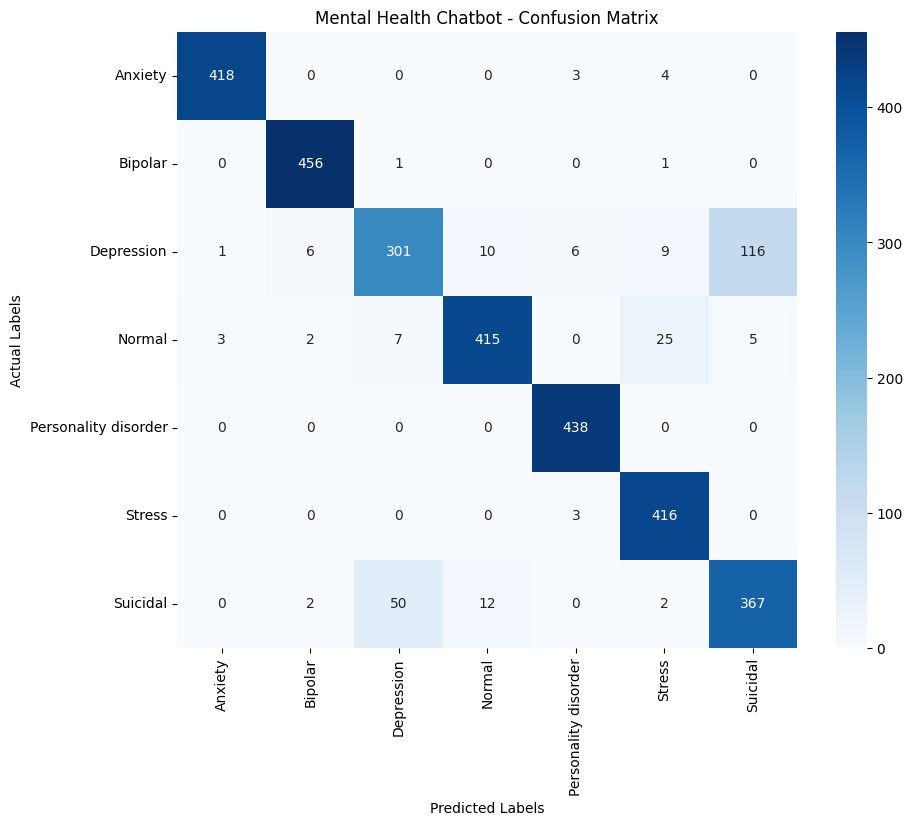

In [63]:
cm = confusion_matrix(y_true, predicted_labels)

# 3. Plotting setup
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)

plt.title('Mental Health Chatbot - Confusion Matrix')
plt.ylabel('Actual Labels')
plt.xlabel('Predicted Labels')
plt.show()

# Save Model

In [65]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [71]:
import os
import pickle
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

save_directory = "/content/drive/MyDrive/MentalHealthModel"


def save_everything(trainer, tokenizer, label_encoder):
    if not os.path.exists(save_directory):
        os.makedirs(save_directory)


    pickle.dump(label_encoder, open(f"{save_directory}/label_encoder.pkl", "wb"))


    trainer.save_model(save_directory)
    tokenizer.save_pretrained(save_directory)

    print(f" Success! Everything saved to: {save_directory}")
    print("- Model weights, Config, Tokenizer & Label Encoder are now safe.")


def load_and_predict(user_message):
    print("\n--- Loading Model for Prediction ---")

    tokenizer = AutoTokenizer.from_pretrained(save_directory)
    model = AutoModelForSequenceClassification.from_pretrained(save_directory)


    with open(f"{save_directory}/label_encoder.pkl", "rb") as f:
        le = pickle.load(f)


    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)


    inputs = tokenizer(user_message, return_tensors="pt", truncation=True, padding=True).to(device)


    with torch.no_grad():
        outputs = model(**inputs)
        prediction = torch.argmax(outputs.logits, dim=1).item()


    detected_state = le.inverse_transform([prediction])[0]

    return detected_state

msg = "I feel very anxious and my heart is racing."
result = load_and_predict(msg)
print(f" Bot Result: Detected state is '{result}'")


--- Loading Model for Prediction ---


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

 Bot Result: Detected state is 'Anxiety'
